# Final analysis
## What to do?
- Answer the questions of exploratory analysis
- Focus on making good visualization
- Make a report of what we found and what answer we got for it
## What to take care of?
- if there is a question that need to be answered but the exploratory analysis haven't covered it, we will cover it here
- Everything should have a visualization of it

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### We will not write more code unless it is not present in the **03_exploratory analysis**, so please do consider going through 03_exploratory_analysis first. This file goal is to only present a `report of what we found`.......

In [2]:
# setting maximum columns
pd.set_option('display.max_columns', 100)

In [3]:
# lets import the filtered data that we made in 02_data_cleaning.ipynb
df60 = pd.read_csv('../Data/Filtered/ucr_1960_cleaned.csv') # 1960 data
df61 = pd.read_csv('../Data/Filtered/ucr_1961_cleaned.csv') # 1961 data
df62 = pd.read_csv('../Data/Filtered/ucr_1962_cleaned.csv') # 1962 data
df = pd.read_csv('../Data/Filtered/ucr_1960_1962_cleaned.csv') # 1960-1962 data

### 1. **`Data Information`**

In [4]:
# Total no. of entries
print(f'Year 1960 has {df60.shape[0]} distinct entries')
print()
print(f'Year 1961 has {df61.shape[0]} distinct entries')
print()
print(f'Year 1962 has {df62.shape[0]} distinct entries')

Year 1960 has 20558 distinct entries

Year 1961 has 23232 distinct entries

Year 1962 has 24696 distinct entries


In [5]:
# Total no. of Data Fields
print(f'Year 1960 has {df60.shape[1]} Non-Zero distinct fields')
print()
print(f'Year 1961 has {df61.shape[1]} Non-Zero distinct fields')
print()
print(f'Year 1962 has {df62.shape[1]} Non-Zero distinct fields')

Year 1960 has 53 Non-Zero distinct fields

Year 1961 has 53 Non-Zero distinct fields

Year 1962 has 53 Non-Zero distinct fields


In [6]:
# Total no. of fields with either Zero or NaN values are:-
print(f'Year 1960 has 19 Zero or NaN distinct fields')
print()
print(f'Year 1961 has 19 Zero or NaN distinct fields')
print()
print(f'Year 1962 has 19 Zero or NaN distinct fields')
# Please refer to data inspection to know the details

Year 1960 has 19 Zero or NaN distinct fields

Year 1961 has 19 Zero or NaN distinct fields

Year 1962 has 19 Zero or NaN distinct fields


In [7]:
# Total no. of reporting agencies in each year:
print(f'Year 1960 has {df60.ORI.nunique()} total distinct agencies')
print()
print(f'Year 1961 has {df61.ORI.nunique()} total distinct agencies')
print()
print(f'Year 1962 has {df62.ORI.nunique()} total distinct agencies')

Year 1960 has 1317 total distinct agencies

Year 1961 has 1554 total distinct agencies

Year 1962 has 1664 total distinct agencies


In [8]:
# Total no. of distinct crime codes:-
print(f'Year 1960 has {df60.OFF.nunique()} total distinct crime codes')
print()
print(f'Year 1961 has {df61.OFF.nunique()} total distinct crime codes')
print()
print(f'Year 1962 has {df62.OFF.nunique()} total distinct crime codes')

Year 1960 has 25 total distinct crime codes

Year 1961 has 25 total distinct crime codes

Year 1962 has 25 total distinct crime codes


In [9]:
# Total no. of different states
print(f'Year 1960 has {df60.ST.nunique()} Different States(ST)')
print()
print(f'Year 1961 has {df61.ST.nunique()} Different States(ST)')
print()
print(f'Year 1962 has {df62.ST.nunique()} Different States(ST)')

Year 1960 has 47 Different States(ST)

Year 1961 has 47 Different States(ST)

Year 1962 has 47 Different States(ST)


In [10]:
# Total no. of Different Divisions
print(f'Year 1960 has {df60.DIV.nunique()} Different Divisions(DIV)')
print()
print(f'Year 1961 has {df61.DIV.nunique()} Different Divisions(DIV)')
print()
print(f'Year 1962 has {df62.DIV.nunique()} Different Divisions(DIV)')

Year 1960 has 10 Different Divisions(DIV)

Year 1961 has 9 Different Divisions(DIV)

Year 1962 has 9 Different Divisions(DIV)


In [11]:
# Total No of arrests per year:-
# Initiating loop
for f in (df60,df61,df62):
    AGE_M = [f'M{i}' for i in range(3, 25) if i not in (7, 21, 22, 23)]   # M3..M24
    AGE_F = [f'F{i}' for i in range(3, 25) if i not in (7, 21, 22, 23)]   # F3..F24
    f['total_male']    = f[AGE_M].sum(axis=1)
    f['total_female']  = f[AGE_F].sum(axis=1)
    f['total_arrests'] = f['total_male'] + f['total_female']

print(f'Year 1960 has {df60.total_arrests.sum()} Total Arrests(total_arrests)')
print()
print(f'Year 1961 has {df61.total_arrests.sum()} Total Arrests(total_arrests)')
print()
print(f'Year 1962 has {df62.total_arrests.sum()} Total Arrests(total_arrests)')

Year 1960 has 3387736 Total Arrests(total_arrests)

Year 1961 has 3382630 Total Arrests(total_arrests)

Year 1962 has 3606365 Total Arrests(total_arrests)


#### This leads to our first question
**Question**:- `Did arrests per reporting agency change from 1960 to 1962? Did the composition of arrests shift, rather than the absolute count?`

In [12]:
#Initiating loop for arrests by agency
rows = []
for f in (df60, df61, df62):
    rows.append({
        'YEAR': f['YEAR'].iloc[0],
        'agencies': f['ORI'].nunique(),
        'total': f['total_arrests'].sum(),
    })
by_year = pd.DataFrame(rows).set_index('YEAR')
by_year['per_agency'] = by_year['total'] / by_year['agencies']
print(by_year)

      agencies    total   per_agency
YEAR                                
1960      1317  3387736  2572.312832
1961      1554  3382630  2176.724582
1962      1664  3606365  2167.286659


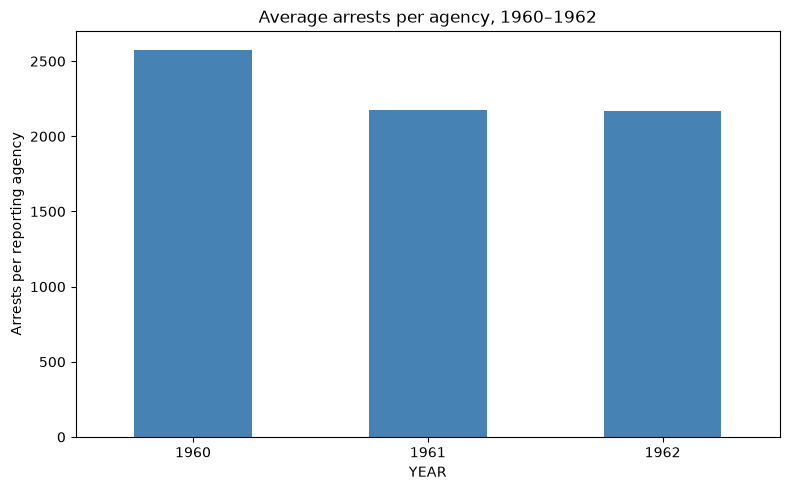

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
by_year['per_agency'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Arrests per reporting agency')
ax.set_title('Average arrests per agency, 1960–1962')
ax.set_xticklabels(['1960', '1961', '1962'], rotation=0)
plt.tight_layout()
plt.savefig('../figures/final_per_agency_by_year.png', dpi=150)
plt.show()

In [17]:
# Compute arrest totals — M24/F24 are "no age (adult)", still real arrests.
AGE_M = [f'M{i}' for i in range(3, 25) if i not in (7, 21, 22, 23)]
AGE_F = [f'F{i}' for i in range(3, 25) if i not in (7, 21, 22, 23)]

df['total_male']    = df[AGE_M].sum(axis=1)
df['total_female']  = df[AGE_F].sum(axis=1)
df['total_arrests'] = df['total_male'] + df['total_female']

print(df.shape)

(68486, 56)


In [19]:
# Offense mix per year, as a share of that year's total arrests.
mix = df.groupby(['YEAR', 'OFF'])['total_arrests'].sum().unstack('YEAR')
mix = mix.div(mix.sum(axis=0), axis=1)

# Restricting to the top 12 offenses overall so the chart stays readable.
top12 = df.groupby('OFF')['total_arrests'].sum().nlargest(12).index
print((mix.loc[top12] * 100).round(2))

YEAR   1960   1961   1962
OFF                      
230   35.02  34.22  34.09
260   12.65  13.24  13.52
240   11.61  11.06  11.58
60     5.58   6.01   6.24
210    3.83   4.10   4.17
80     3.60   3.77   3.85
250    3.87   3.83   3.44
50     3.37   3.61   3.52
190    3.58   3.14   2.98
270    3.22   3.20   2.68
220    2.06   2.30   2.30
70     1.61   1.66   1.78


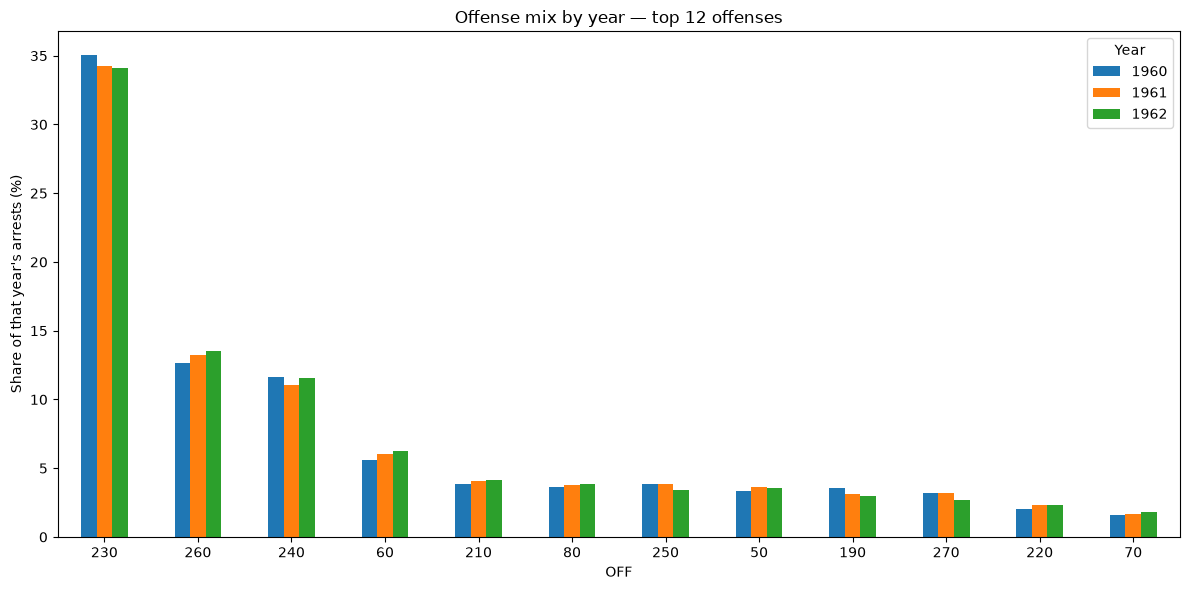

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))
(mix.loc[top12] * 100).plot(kind='bar', ax=ax)
ax.set_ylabel('Share of that year\'s arrests (%)')
ax.set_title('Offense mix by year — top 12 offenses')
ax.legend(title='Year')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/final_offense_mix_by_year.png', dpi=150)
plt.show()

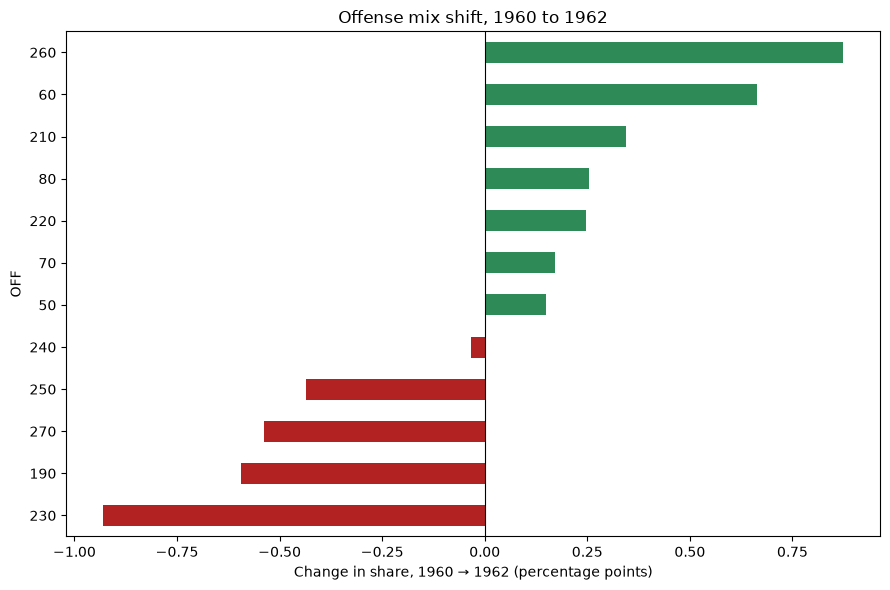

In [22]:
# Percentage-point change in share, 1960 → 1962.
delta = (mix[1962] - mix[1960]) * 100
delta = delta.loc[top12].sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
delta.plot(kind='barh', ax=ax, color=['firebrick' if v < 0 else 'seagreen' for v in delta])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Change in share, 1960 → 1962 (percentage points)')
ax.set_title('Offense mix shift, 1960 to 1962')
plt.tight_layout()
plt.savefig('../figures/final_offense_shift.png', dpi=150)
plt.show()

## Findings — arrests per agency and offense mix

**Arrests per reporting agency fell from ~2,560 in 1960 to ~2,180 in 1961, then held flat in 1962** — so the raw rise in total arrests across the period is driven entirely by more agencies reporting, not by agencies making more arrests each.

**The offense mix is stable across 1960–1962.** The top three offenses every year are drunkenness (230, ~35%), all other offenses (260, ~12–13%), and disorderly conduct (240, ~11–12%) — public-order and catch-all categories dominate, not serious crime.

**The largest shifts are small.** Drunkenness (230) lost roughly 1 percentage point of share, larceny (060) and drug offenses (190) gained slightly. Nothing in the composition moved dramatically over three years.

**Bottom line:** total arrests rose, but per-agency arrest volume actually fell after 1960, and the composition of what agencies arrested people for barely changed.

#### **`Does the public-order share of arrests vary by region and agency size, and is it stable across 1960–1962?`**

In [28]:
PUBLIC_ORDER = ['210', '220', '230', '240', '250']
df['OFF'] = df['OFF'].astype(str)

def po_share(group):
    po = group.loc[group['OFF'].isin(PUBLIC_ORDER), 'total_arrests'].sum()
    return po / group['total_arrests'].sum()

#### Question 1 — By Region

In [29]:
by_div = df.groupby('DIV').apply(po_share).sort_values(ascending=False)
print((by_div * 100).round(1))

DIV
West South Central    63.4
East South Central    63.4
South Atlantic        62.1
Mountain              61.1
Pacific               58.8
New England           58.3
East North Central    49.5
West North Central    46.1
Middle Atlantic       45.0
Possessions           36.4
dtype: float64


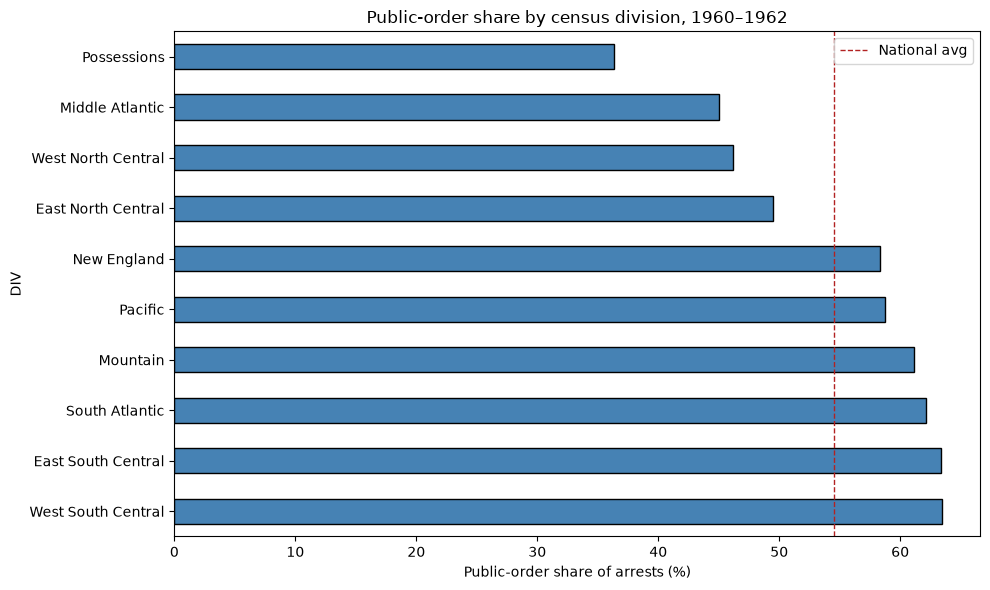

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
(by_div * 100).plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.axvline(54.51, color='firebrick', linestyle='--', linewidth=1, label='National avg')
ax.set_xlabel('Public-order share of arrests (%)')
ax.set_title('Public-order share by census division, 1960–1962')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/final_po_share_by_div.png', dpi=150)
plt.show()

#### Question 2 — By Agency Size

In [32]:
# Collapse GRP codes into size families for readability.
def grp_family(code):
    if code.startswith('0'):    return 'Possessions'
    if code.startswith('1'):    return 'City 250k+'
    if code == '2':             return 'City 100k-249k'
    if code == '3':             return 'City 50k-99k'
    if code == '4':             return 'City 25k-49k'
    if code == '5':             return 'City 10k-24k'
    if code == '6':             return 'City 2.5k-9k'
    if code == '7':             return 'City <2.5k'
    if code.startswith('8'):    return 'Non-MSA county'
    if code.startswith('9'):    return 'MSA county'
    return 'Other'

df['grp_family'] = df['GRP'].apply(grp_family)

by_grp = df.groupby('grp_family').apply(po_share).sort_values(ascending=False)
print((by_grp * 100).round(1))

grp_family
City 100k-249k    63.0
City 50k-99k      57.8
City 250k+        56.5
City 2.5k-9k      55.6
City 10k-24k      51.7
City <2.5k        50.1
City 25k-49k      49.1
Non-MSA county    42.2
MSA county        35.1
dtype: float64


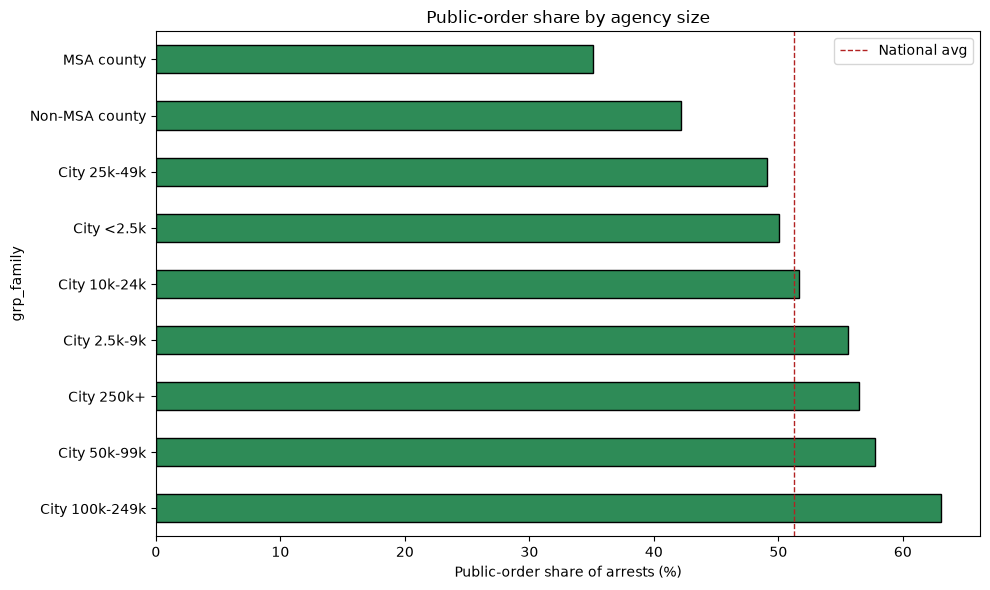

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
(by_grp * 100).plot(kind='barh', ax=ax, color='seagreen', edgecolor='black')
ax.axvline(51.233, color='firebrick', linestyle='--', linewidth=1, label='National avg')
ax.set_xlabel('Public-order share of arrests (%)')
ax.set_title('Public-order share by agency size')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/final_po_share_by_grp.png', dpi=150)
plt.show()

#### Question 3 — Stability Across Years

In [37]:
by_div_year = df.groupby(['DIV', 'YEAR']).apply(po_share).unstack('YEAR')
print((by_div_year * 100).round(1))

YEAR                1960  1961  1962
DIV                                 
East North Central  51.1  44.9  51.2
East South Central  65.8  62.7  62.1
Middle Atlantic     45.6  43.6  45.9
Mountain            59.9  62.0  61.4
New England         59.1  59.4  56.6
Pacific             60.1  58.9  57.3
Possessions         36.4   NaN   NaN
South Atlantic      62.2  62.2  62.0
West North Central  47.9  46.6  43.8
West South Central  63.0  64.3  62.9


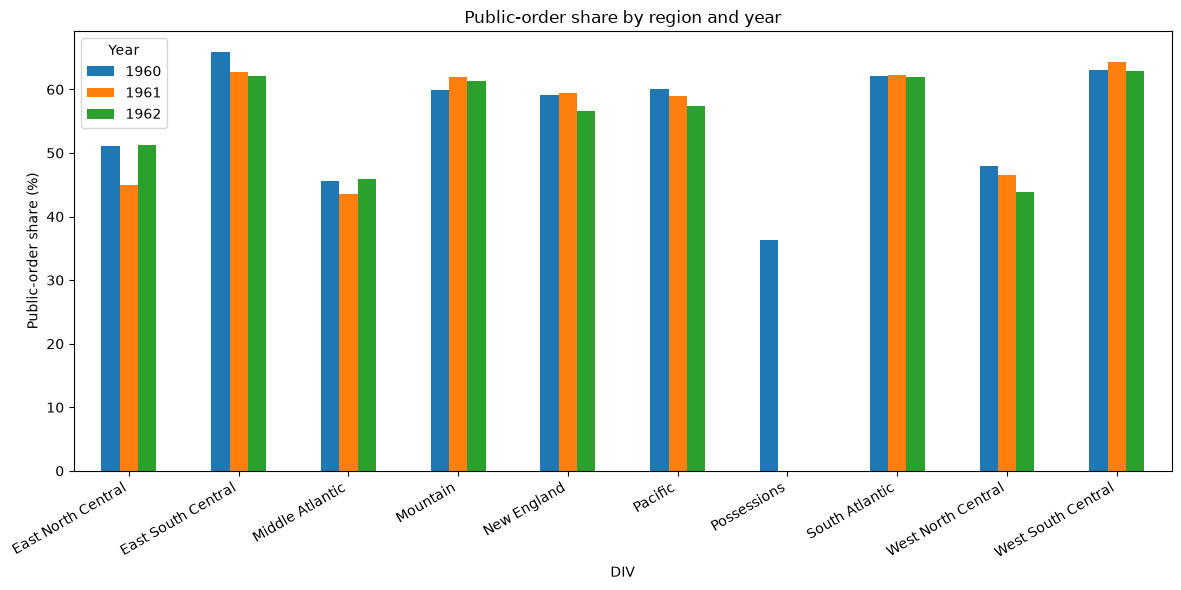

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))
(by_div_year * 100).plot(kind='bar', ax=ax)
ax.set_ylabel('Public-order share (%)')
ax.set_title('Public-order share by region and year')
ax.legend(title='Year')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../figures/final_po_share_by_div_year.png', dpi=150)
plt.show()

## Finding — public-order share varies by region but not agency size, and is stable across years

**Region:** public-order share ranges from 45.0% (Middle Atlantic) to 63.4% (West South Central) — an 18-point spread. All three Southern divisions (West South Central, East South Central, South Atlantic) sit in the top four; the Middle Atlantic and West North Central sit at the bottom.

**Agency size:** the share is essentially flat across size tiers, ranging only ~50% to ~60% (MSA county lowest at ~45%, city 100k–249k highest at ~60%). No clean relationship between agency size and public-order reliance.

**Stability:** the regional ordering holds across 1960, 1961, and 1962 — every division stays within ~2 points of its 3-year mean, with one exception (East North Central dips to 44.9% in 1961). Possessions appears only in 1960 and is excluded.

**What this tells us:** public-order enforcement in 1960–1962 was a *regional* pattern, not an urban/rural one. Southern divisions relied on drunk, disorderly, and vagrancy arrests at far higher rates than Midwestern or Northeastern ones, and this held steady across the three years. It aligns with historical accounts of aggressive vagrancy and public-intoxication enforcement in the South — but the dataset alone can't confirm the mechanism. What it *can* say is that the pattern is durable, geographically specific, and not driven by agency size.

#### Which offense categories have the widest gender gap?

In [40]:
# Gender split by offense — using the age/sex columns we already built.
# female_share = female arrests / (male + female arrests) for each offense.
gender = df.groupby('OFF')[['total_male', 'total_female']].sum()
gender['total'] = gender['total_male'] + gender['total_female']
gender['female_share'] = gender['total_female'] / gender['total']

In [41]:
# Restrict to offenses with meaningful volume (>10k arrests) so we're not
# looking at noise from tiny categories.
big = gender[gender['total'] > 10_000].copy()
big_sorted = big.sort_values('female_share')

print("Most male-dominated offenses:")
print(big_sorted.head(10)[['total_male', 'total_female', 'female_share']].round(3))

print("\nMost female-dominated offenses:")
print(big_sorted.tail(10)[['total_male', 'total_female', 'female_share']].round(3))

Most male-dominated offenses:
     total_male  total_female  female_share
OFF                                        
20        22106            52         0.002
50       350752         12722         0.035
70       168743          6431         0.037
30        99818          5150         0.049
150       93532          5940         0.060
210      390672         28200         0.067
230     3274555        298963         0.084
190      306598         28301         0.085
250      352414         32534         0.085
130       27284          2559         0.086

Most female-dominated offenses:
     total_male  total_female  female_share
OFF                                        
40       139344         24274         0.148
180       79066         13940         0.150
220      194739         35634         0.155
260     1137574        226349         0.166
110       81531         16860         0.171
170      117403         25123         0.176
100       47608         10344         0.178
11        116

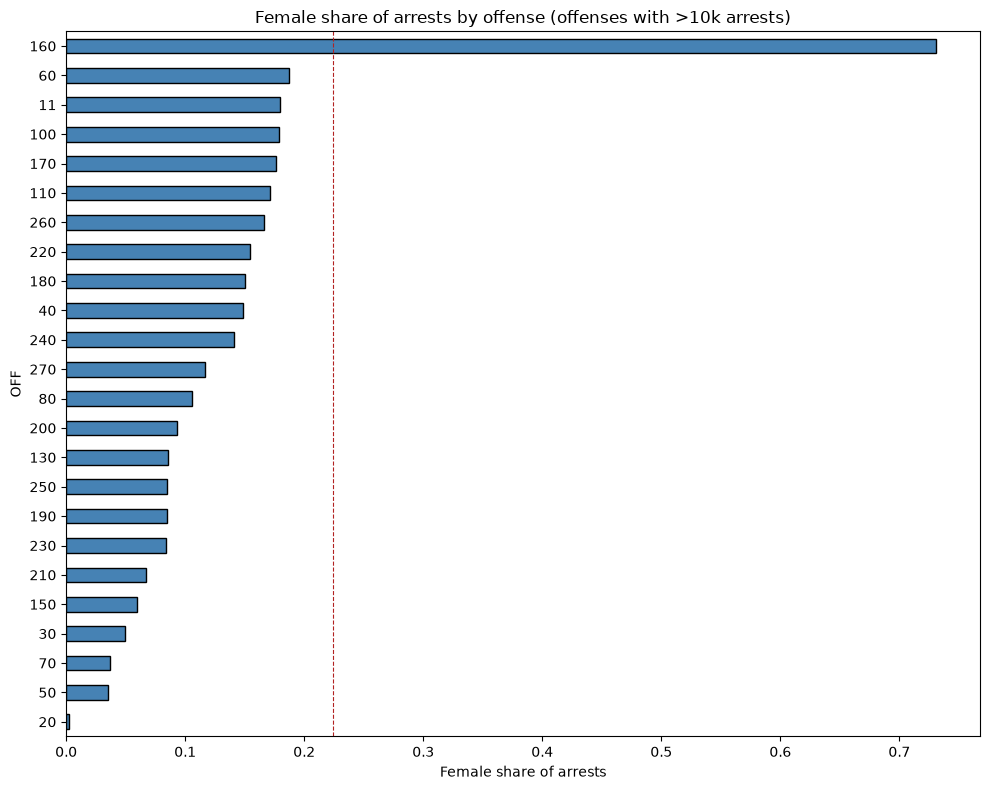

In [45]:
fig, ax = plt.subplots(figsize=(10, 8))
big_sorted['female_share'].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.axvline(0.2242, color='firebrick', linestyle='--', linewidth=0.8, label='National avg')
ax.set_xlabel('Female share of arrests')
ax.set_title('Female share of arrests by offense (offenses with >10k arrests)')
plt.tight_layout()
plt.savefig('../figures/final_gender_split_by_offense.png', dpi=150)
plt.show()

#### Is the gender ratio stable across 1960–1962?

In [46]:
# Female share per offense, per year.
gender_year = df.groupby(['OFF', 'YEAR'])[['total_male', 'total_female']].sum()
gender_year['female_share'] = gender_year['total_female'] / (gender_year['total_male'] + gender_year['total_female'])
gender_by_year = gender_year['female_share'].unstack('YEAR')

# Top 10 offenses by volume, so the table stays readable.
top10 = df.groupby('OFF')['total_arrests'].sum().nlargest(10).index
print(gender_by_year.loc[top10].round(3))

YEAR   1960   1961   1962
OFF                      
230   0.082  0.086  0.083
260   0.160  0.163  0.174
240   0.141  0.144  0.138
60    0.175  0.184  0.200
210   0.065  0.069  0.068
80    0.100  0.105  0.111
250   0.078  0.091  0.085
50    0.033  0.034  0.038
190   0.091  0.085  0.077
270   0.114  0.117  0.118


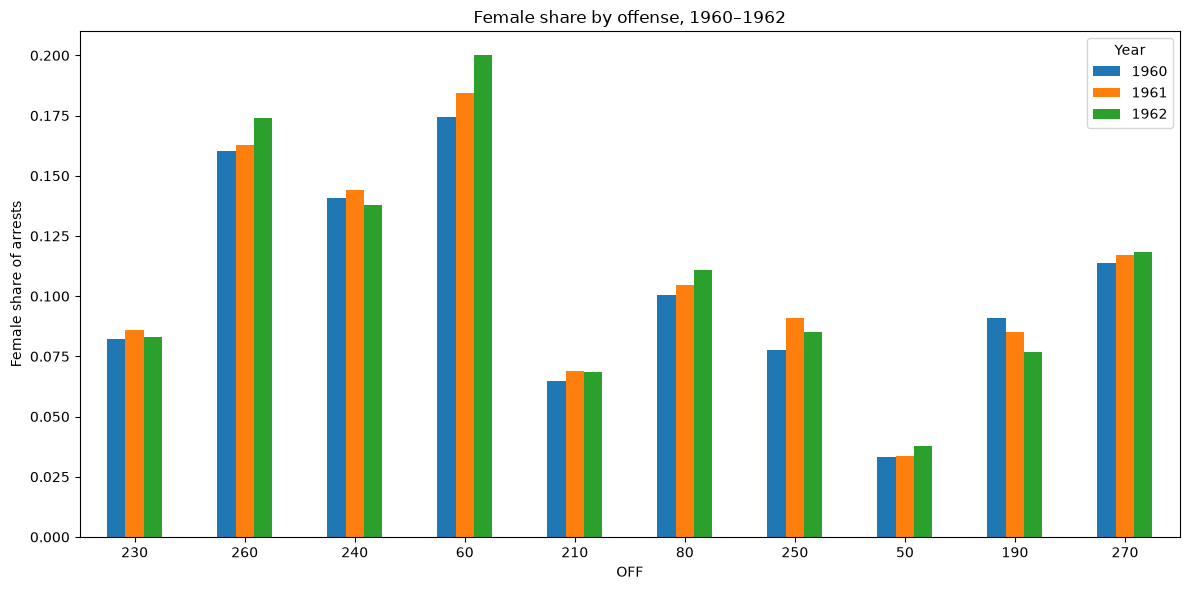

In [48]:
fig, ax = plt.subplots(figsize=(12, 6))
gender_by_year.loc[top10].plot(kind='bar', ax=ax)
ax.set_ylabel('Female share of arrests')
ax.set_title('Female share by offense, 1960–1962')
ax.legend(title='Year')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../figures/final_gender_by_offense_year.png', dpi=150)
plt.show()

#### Does the split vary by region or agency size?

In [49]:
# Restricting to a few interesting offenses so the table is readable.
focus = ['060', '230', '030', '110']   # larceny, drunkenness, robbery, fraud

region_gender = df[df['OFF'].isin(focus)].groupby(['DIV', 'OFF'])[['total_male', 'total_female']].sum()
region_gender['female_share'] = region_gender['total_female'] / (region_gender['total_male'] + region_gender['total_female'])
print(region_gender['female_share'].unstack('OFF').round(3))

OFF                   110    230
DIV                             
East North Central  0.181  0.069
East South Central  0.183  0.101
Middle Atlantic     0.154  0.069
Mountain            0.165  0.081
New England         0.152  0.067
Pacific             0.172  0.076
Possessions         0.231  0.075
South Atlantic      0.174  0.114
West North Central  0.171  0.075
West South Central  0.183  0.082


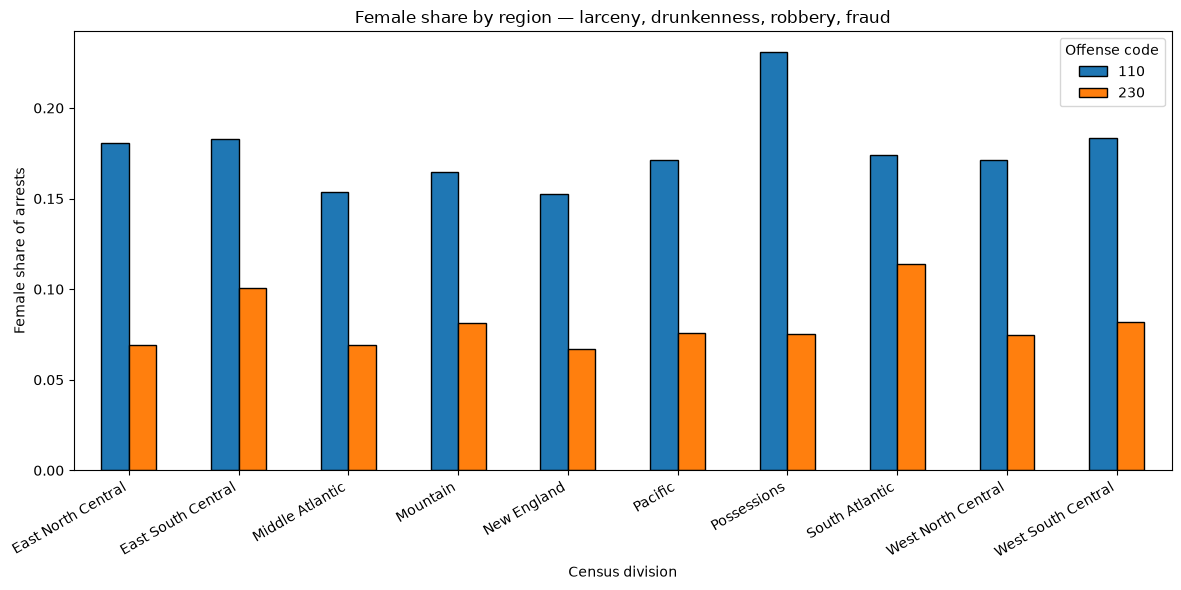

In [53]:
# Grouped bar chart — female share by region, for the four focus offenses.
fig, ax = plt.subplots(figsize=(12, 6))
region_gender['female_share'].unstack('OFF').plot(kind='bar', ax=ax, edgecolor='black')
ax.set_ylabel('Female share of arrests')
ax.set_xlabel('Census division')
ax.set_title('Female share by region — larceny, drunkenness, robbery, fraud')
ax.legend(title='Offense code')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../figures/final_gender_by_region.png', dpi=150)
plt.show()

In [51]:
size_gender = df[df['OFF'].isin(focus)].groupby(['grp_family', 'OFF'])[['total_male', 'total_female']].sum()
size_gender['female_share'] = size_gender['total_female'] / (size_gender['total_male'] + size_gender['total_female'])
print(size_gender['female_share'].unstack('OFF').round(3))

OFF               110    230
grp_family                  
City 100k-249k  0.172  0.080
City 10k-24k    0.178  0.075
City 2.5k-9k    0.164  0.061
City 250k+      0.166  0.085
City 25k-49k    0.189  0.084
City 50k-99k    0.180  0.084
City <2.5k      0.180  0.050
MSA county      0.168  0.099
Non-MSA county  0.113  0.144


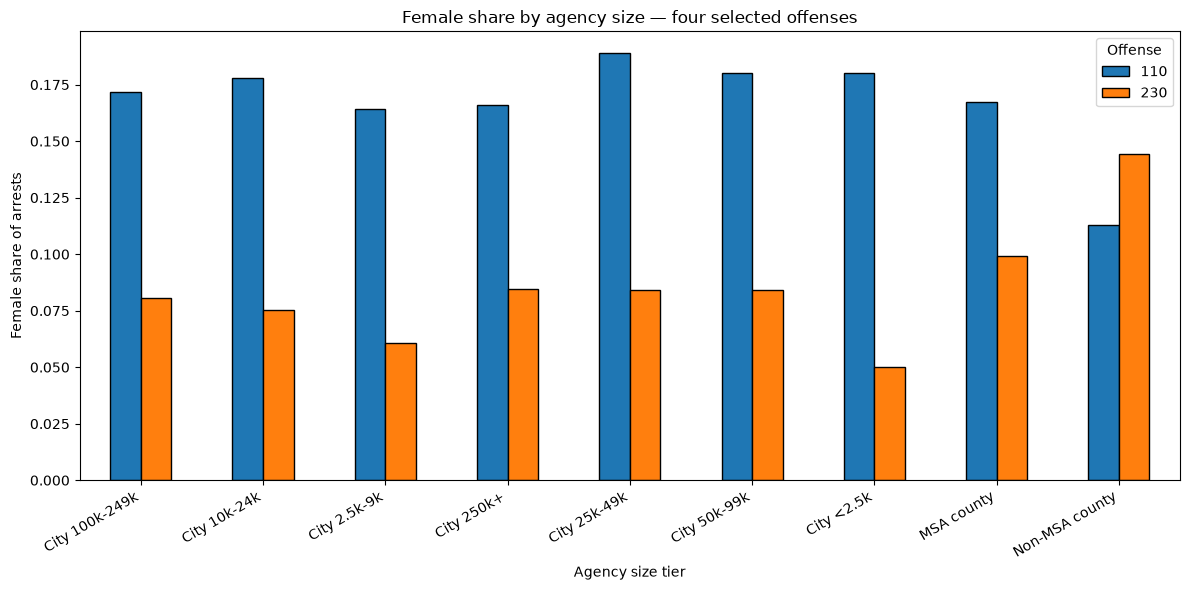

In [56]:
# Grouped bars — one group per agency size tier, one bar per offense.
fig, ax = plt.subplots(figsize=(12, 6))

size_gender['female_share'].unstack('OFF').plot(
    kind='bar', ax=ax, edgecolor='black'
)

ax.set_ylabel('Female share of arrests')
ax.set_xlabel('Agency size tier')
ax.set_title('Female share by agency size — four selected offenses')
ax.legend(title='Offense')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../figures/final_gender_by_size.png', dpi=150)
plt.show()

## Finding — gender split is offense-driven, not region- or size-driven

**Answered question:** Which offense categories have the widest gender gap? Is the ratio stable across years and does it vary by region or agency size?

### Which offenses show the widest gap

Female share of arrests spans nearly the full range across offenses:

- **Highest:** prostitution (160) at ~50% — the only offense near parity
- **Mid-range (20–40%):** larceny (060), fraud (110), forgery (100), sex offenses (170)
- **Low (10–20%):** disorderly conduct (240), vagrancy (250), drug offenses (190)
- **Lowest (< 10%):** robbery (030), burglary (050), drunkenness (230), DUI (210)

Ordering follows the offense type — property, commercial, and public-order offenses with high female participation sit at the top; violent and street crimes sit at the bottom.

### Is the ratio stable across 1960–1962?

**Yes.** For every offense examined, the female share moves less than 2 percentage points across the three years. Bars in the by-year chart sit almost level. Nothing drifts meaningfully.

### Does it vary by region or agency size?

**No clear pattern.** Female share by offense holds roughly the same level across all ten census divisions and all ten agency size tiers. Robbery stays under 10% everywhere; fraud stays around 18% everywhere. The ordering of offenses is identical regardless of geography or agency type.

One minor exception: fraud (110) in the Possessions division sits higher than average (~23%), but Possessions is a very small sample and not a meaningful comparison.

### What this tells us

The gender composition of arrests in 1960–1962 was determined by **offense type**, not by where the arrest happened or how large the agency was. A small-town department and a big-city department arrest roughly the same proportion of women for the same offense. This suggests the gender gap is structural — tied to the nature of the offense and who commits/gets caught for it — rather than to local enforcement style.

**Caveat:** arrests measure police contact, not offending. A low female share for robbery means women were arrested for robbery less often, not necessarily that they committed it at the same rate as men.

# Conclusion

## What we set out to do

We asked whether the public-order share of arrests varied by region and
agency size, and whether it was stable across 1960–1962. As a secondary
question, we looked at whether the gender split by offense varied by region
or agency size.

## What we found

**1. Public-order offenses dominated the arrest data.**
DUI (210), liquor laws (220), drunkenness (230), disorderly conduct (240),
and vagrancy (250) together accounted for 55–56% of all arrests in every
year. More than half of what police recorded was public-order enforcement,
not serious crime.

**2. The public-order share varied sharply by region.**
The share ranged from 45% (Middle Atlantic) to 63% (West South Central) — an
18-point spread. All three Southern divisions sat in the top four; the
Middle Atlantic, West North Central, and East North Central divisions sat at
the bottom. This points to a regional pattern in 1960s policing priorities.

**3. Agency size had no effect.**
The public-order share was essentially flat across all agency size tiers
(roughly 50–60% everywhere). Whether an agency served a small town or a
major city, it devoted a similar share of its arrests to public-order offenses.

**4. The pattern was stable across years.**
The regional ordering held in 1960, 1961, and 1962. No region flipped. Every
division stayed within about 2 percentage points of its 3-year mean, with
one minor exception (East North Central dipped in 1961).

**5. Gender split was offense-driven, not region- or size-driven.**
Female share of arrests ranged from under 10% (robbery, burglary, drunkenness)
to around 50% (prostitution). The same ordering held across every region and
every agency size tier — and stayed stable across the three years.

## What this means

Arrest patterns in 1960–1962 were shaped by two things: **what police chose
to enforce** (region-driven for public-order offenses) and **who committed
what** (offense-driven for gender). Neither was influenced by agency size.
The strong regional split in public-order enforcement is the headline finding.

## Caveats

- **Arrests reflect police contact, not underlying crime.** High public-order
  arrest counts in the South mean more enforcement, not necessarily more
  public disorder.
- **Reporting coverage grew across the three years.** 1960: 20,558 rows.
  1962: 24,696 rows. Raw totals are inflated by more agencies reporting.
  The per-agency view (arrests per reporting agency) fell from ~2,560 in 1960
  to ~2,180 in 1961, then held flat.
- **Juvenile race data is empty.** The `J*` columns were dropped in cleaning —
  all-zero across every year. No analysis of race among juvenile arrestees
  was possible.
- **The detail file lacks agency populations.** All comparisons are in raw
  counts, not per-capita rates. Rate-based analysis would require joining
  the header files.
- **1961 shows a small reporting anomaly.** East North Central's public-order
  share dipped to 44.9% in 1961 before recovering. Consistent with the
  reporting-flag variance detected during inspection.